# Notebook 02 — Audit de la qualité des données

## Objectif

Ce notebook évalue la qualité du dataset intégré avant les étapes de prétraitement et de construction des variables analytiques.

Les contrôles portent sur :

- la structure du dataset ;
- les valeurs manquantes ;
- les doublons ;
- la cohérence des variables numériques ;
- la cohérence temporelle et hiérarchique.

L’objectif est d’identifier les éventuels problèmes de qualité et de fournir une synthèse exploitable avant le Notebook 03.

In [1]:
# =============================================================================
# Import des bibliothèques
# =============================================================================
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# =============================================================================
# Configuration générale
# =============================================================================

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.frameon": False
})

In [9]:
# =============================================================================
# Définition des chemins du projet
# =============================================================================
PROJECT_DIR = Path.cwd().parent
DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = DATA_DIR / "results"
QUALITY_DIR = RESULTS_DIR / "data_quality"

QUALITY_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DATASET_PATH = PROCESSED_DIR / "dataset_raw.csv"

In [10]:
# =============================================================================
# Chargement du jeu de données
# =============================================================================

df = pd.read_csv(DATASET_PATH)

print(f"Dataset chargé : {df.shape[0]:,} observations × {df.shape[1]} variables")


Dataset chargé : 74,888 observations × 15 variables


# Partie 2 - Compréhension du jeu de données

Cette étape consiste à réaliser un inventaire complet des variables du jeu de données.

L'objectif est de comprendre la structure des données avant d'analyser leur qualité.

Le résultat principal de cette partie est un tableau récapitulatif contenant les principales caractéristiques de chaque variable.

In [11]:
# Tableau descriptif des variables

variables_summary = pd.DataFrame({
    "Variable": df.columns,
    "Type": df.dtypes.astype(str),
    "Valeurs_uniques": df.nunique(dropna=True),
    "Valeurs_manquantes": df.isna().sum(),
    "Pourcentage_manquant (%)": (df.isna().mean() * 100).round(2)
}).sort_values(
    "Pourcentage_manquant (%)",
    ascending=False
).reset_index(drop=True)

display(variables_summary)

,Variable,Type,Valeurs_uniques,Valeurs_manquantes,Pourcentage_manquant (%)
0,Tx M3N MDH Inter N-1,str,850,68676,91.70
1,Tx M3N MDH Inter N,str,1129,59413,79.34
2,Tx M3N non CP N-1,str,5672,54640,72.96
3,Average Purchasing Price N-1,float64,22395,48388,64.61
4,Average Selling Price N-1,float64,22169,48388,64.61
5,Tx M3N non CP N,str,1663,21895,29.24
6,Average Purchasing Price N,float64,54507,6305,8.42
7,Average selling price N,float64,55157,6305,8.42
8,EAN,float64,5860,164,0.22
9,International Sub Department,str,3,0,0.00


In [13]:
# Synthèse de la structure du dataset

nb_num = len(df.select_dtypes(include=np.number).columns)
nb_cat = len(df.select_dtypes(exclude=np.number).columns)

constant_variables = variables_summary[
    variables_summary["Valeurs_uniques"] <= 1
]

high_cardinality = variables_summary[
    variables_summary["Valeurs_uniques"] > 100
]

structure_summary = pd.DataFrame({
    "Indicateur": [
        "Nombre de lignes",
        "Nombre de colonnes",
        "Variables numériques",
        "Variables catégorielles",
        "Variables constantes",
        "Variables à forte cardinalité"
    ],
    "Valeur": [
        len(df),
        df.shape[1],
        nb_num,
        nb_cat,
        len(constant_variables),
        len(high_cardinality)
    ]
})

display(structure_summary)

,Indicateur,Valeur
0,Nombre de lignes,74888
1,Nombre de colonnes,15
2,Variables numériques,6
3,Variables catégorielles,9
4,Variables constantes,0
5,Variables à forte cardinalité,9


# Partie 3 — Analyse des valeurs manquantes

Les valeurs manquantes sont quantifiées globalement et par variable.

Une absence de donnée n'est pas automatiquement considérée comme une erreur : certaines variables historiques ou économiques peuvent naturellement être indisponibles selon le produit et la période.

In [14]:
# Synthèse des valeurs manquantes

missing_summary = pd.DataFrame({
    "Variable": df.columns,
    "Valeurs_manquantes": df.isna().sum(),
    "Pourcentage_manquant (%)": (df.isna().mean() * 100).round(2)
}).sort_values(
    "Pourcentage_manquant (%)",
    ascending=False
).reset_index(drop=True)

total_cells = df.shape[0] * df.shape[1]
total_missing = int(df.isna().sum().sum())
global_missing_rate = total_missing / total_cells * 100

print(f"Valeurs manquantes : {total_missing:,}")
print(f"Taux global        : {global_missing_rate:.2f} %")

display(missing_summary)

Valeurs manquantes : 314,174
Taux global        : 27.97 %


,Variable,Valeurs_manquantes,Pourcentage_manquant (%)
0,Tx M3N MDH Inter N-1,68676,91.70
1,Tx M3N MDH Inter N,59413,79.34
2,Tx M3N non CP N-1,54640,72.96
3,Average Purchasing Price N-1,48388,64.61
4,Average Selling Price N-1,48388,64.61
5,Tx M3N non CP N,21895,29.24
6,Average Purchasing Price N,6305,8.42
7,Average selling price N,6305,8.42
8,EAN,164,0.22
9,International Sub Department,0,0.00


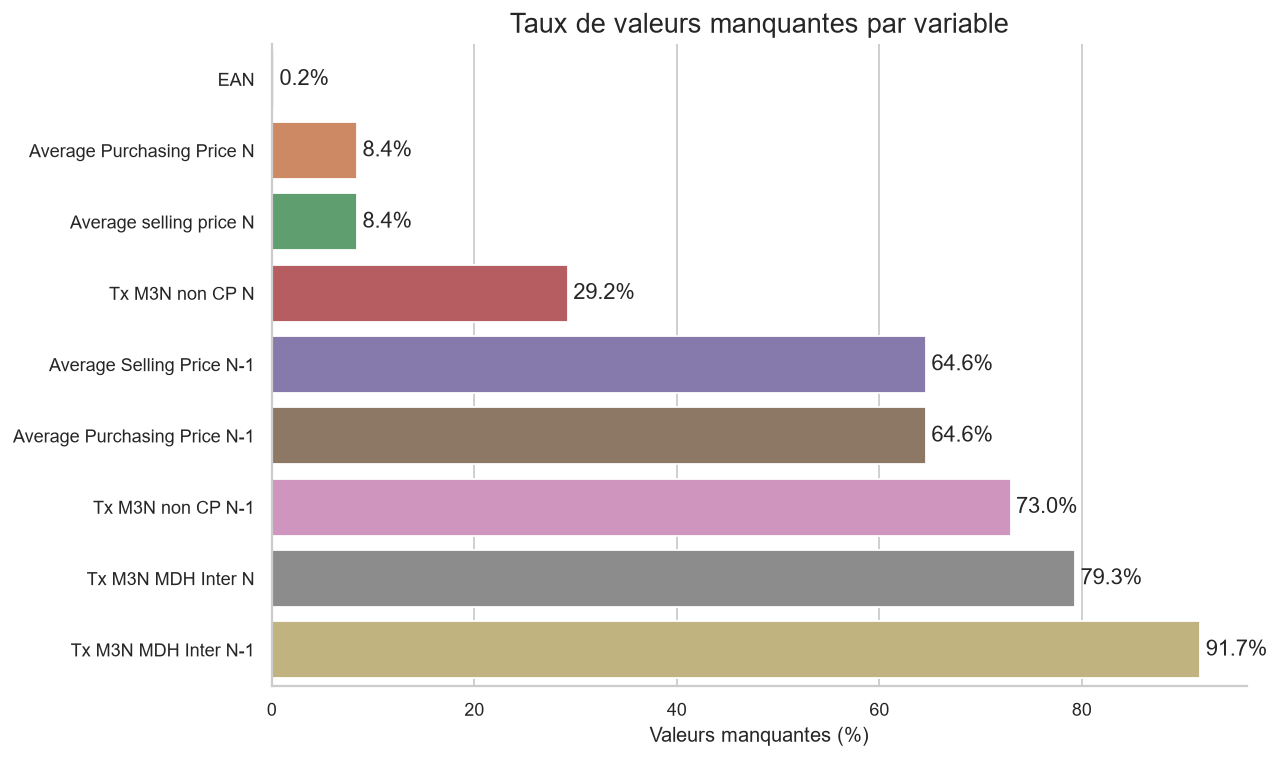

In [15]:
# Visualisation — taux de valeurs manquantes

missing_plot = (
    missing_summary[
        missing_summary["Valeurs_manquantes"] > 0
    ]
    .sort_values("Pourcentage_manquant (%)", ascending=True)
)

if not missing_plot.empty:
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.barplot(
        data=missing_plot,
        x="Pourcentage_manquant (%)",
        y="Variable",
        hue="Variable",
        legend=False,
        ax=ax
    )

    ax.set_title("Taux de valeurs manquantes par variable")
    ax.set_xlabel("Valeurs manquantes (%)")
    ax.set_ylabel("")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3)

    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("Aucune valeur manquante détectée.")

### Interprétation

Les indicateurs N-1 présentent une disponibilité plus faible que les variables de période courante. Ces absences peuvent notamment correspondre à l'absence d'historique comparable pour certains produits.

Le traitement des valeurs manquantes est réalisé dans le notebook de prétraitement, et non dans cet audit.

# Partie 4 — Analyse des doublons

Deux niveaux de contrôle sont réalisés :

- les doublons exacts, correspondant à des lignes entièrement identiques ;
- l'unicité métier selon la combinaison **Année – Mois – EAN**.

Un même EAN peut naturellement apparaître sur plusieurs périodes ; cette répétition n'est donc pas considérée comme un doublon.

In [16]:
# Doublons exacts

exact_duplicates = df[df.duplicated(keep=False)]

# Doublons métier : une observation EAN _ période doit être unique
missing_ean = int(df["EAN"].isna().sum())

df_with_ean = df[df["EAN"].notna()].copy()

business_duplicates = (
    df_with_ean[
        df_with_ean.duplicated(
            subset=["Year", "MonthLib", "EAN"],
            keep=False
        )
    ]
    .sort_values(["Year", "MonthLib", "EAN"])
)

duplicates_summary = pd.DataFrame({
    "Contrôle": [
        "Doublons exacts",
        "Doublons métier (Year - MonthLib - EAN)"
    ],
    "Nombre": [
        len(exact_duplicates),
        len(business_duplicates)
    ]
})

print(f"EAN manquants       : {missing_ean}")
print(f"Doublons exacts     : {len(exact_duplicates)}")
print(f"Doublons métier     : {len(business_duplicates)}")

display(duplicates_summary)

if len(business_duplicates) > 0:
    display(
        business_duplicates[
            ["Year", "MonthLib", "EAN", "International Family"]
        ].head(20)
    )

EAN manquants       : 164
Doublons exacts     : 0
Doublons métier     : 0


,Contrôle,Nombre
0,Doublons exacts,0
1,Doublons métier (Year - MonthLib - EAN),0


# Partie 5 — Audit des variables numériques

Les contrôles portent sur les prix et les taux de marge utilisés ensuite dans les règles métier et la détection multivariée.

Les valeurs extrêmes ne sont pas supprimées dans ce notebook : elles sont identifiées et conservées pour être traitées selon leur contexte dans les étapes suivantes.

In [17]:
# Définition des familles de variables

time_columns = ["Year"]

price_columns = [
    "Average Purchasing Price N",
    "Average selling price N",
    "Average Purchasing Price N-1",
    "Average Selling Price N-1"
]

margin_columns = [
    "Tx M3N MDH Inter N",
    "Tx M3N non CP N",
    "Tx M3N MDH Inter N-1",
    "Tx M3N non CP N-1"
]

In [18]:
# Contrôle des années

valid_years = [2025, 2026]

invalid_years = df[
    ~df["Year"].isin(valid_years)
]

print(f"Années non attendues : {len(invalid_years)}")

if len(invalid_years) > 0:
    display(invalid_years[["Year"]].drop_duplicates())

Années non attendues : 0


In [19]:
# Contrôles des prix négatifs et nuls

negative_prices = pd.DataFrame({
    "Variable": price_columns,
    "Prix_négatifs": [
        int((df[column] < 0).sum())
        for column in price_columns
    ]
})

zero_prices = pd.DataFrame({
    "Variable": price_columns,
    "Prix_nuls": [
        int((df[column] == 0).sum())
        for column in price_columns
    ]
})

print(f"Prix négatifs : {negative_prices['Prix_négatifs'].sum():,}")
print(f"Prix nuls     : {zero_prices['Prix_nuls'].sum():,}")

display(
    negative_prices[
        negative_prices["Prix_négatifs"] > 0
    ]
)

display(
    zero_prices[
        zero_prices["Prix_nuls"] > 0
    ]
)

Prix négatifs : 86
Prix nuls     : 20


,Variable,Prix_négatifs
0,Average Purchasing Price N,21
1,Average selling price N,41
2,Average Purchasing Price N-1,18
3,Average Selling Price N-1,6


,Variable,Prix_nuls
1,Average selling price N,11
3,Average Selling Price N-1,9


In [20]:
# Conversion des taux de marge au format numérique

for column in margin_columns:
    df[column] = (
        df[column]
        .astype("string")
        .str.replace("%", "", regex=False)
        .str.replace(",", ".", regex=False)
        .str.strip()
    )

    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

In [21]:
# Contrôles des taux de marge

high_margin = pd.DataFrame({
    "Variable": margin_columns,
    "Valeurs_supérieures_100": [
        int((df[column] > 100).sum())
        for column in margin_columns
    ]
})

low_margin = pd.DataFrame({
    "Variable": margin_columns,
    "Valeurs_inférieures_-100": [
        int((df[column] < -100).sum())
        for column in margin_columns
    ]
})

print(f"Marges > 100 %  : {high_margin['Valeurs_supérieures_100'].sum():,}")
print(f"Marges < -100 % : {low_margin['Valeurs_inférieures_-100'].sum():,}")

display(
    high_margin[
        high_margin["Valeurs_supérieures_100"] > 0
    ]
)

display(
    low_margin[
        low_margin["Valeurs_inférieures_-100"] > 0
    ]
)

Marges > 100 %  : 111
Marges < -100 % : 246


,Variable,Valeurs_supérieures_100
0,Tx M3N MDH Inter N,48
1,Tx M3N non CP N,34
2,Tx M3N MDH Inter N-1,21
3,Tx M3N non CP N-1,8


,Variable,Valeurs_inférieures_-100
0,Tx M3N MDH Inter N,27
1,Tx M3N non CP N,165
2,Tx M3N MDH Inter N-1,4
3,Tx M3N non CP N-1,50


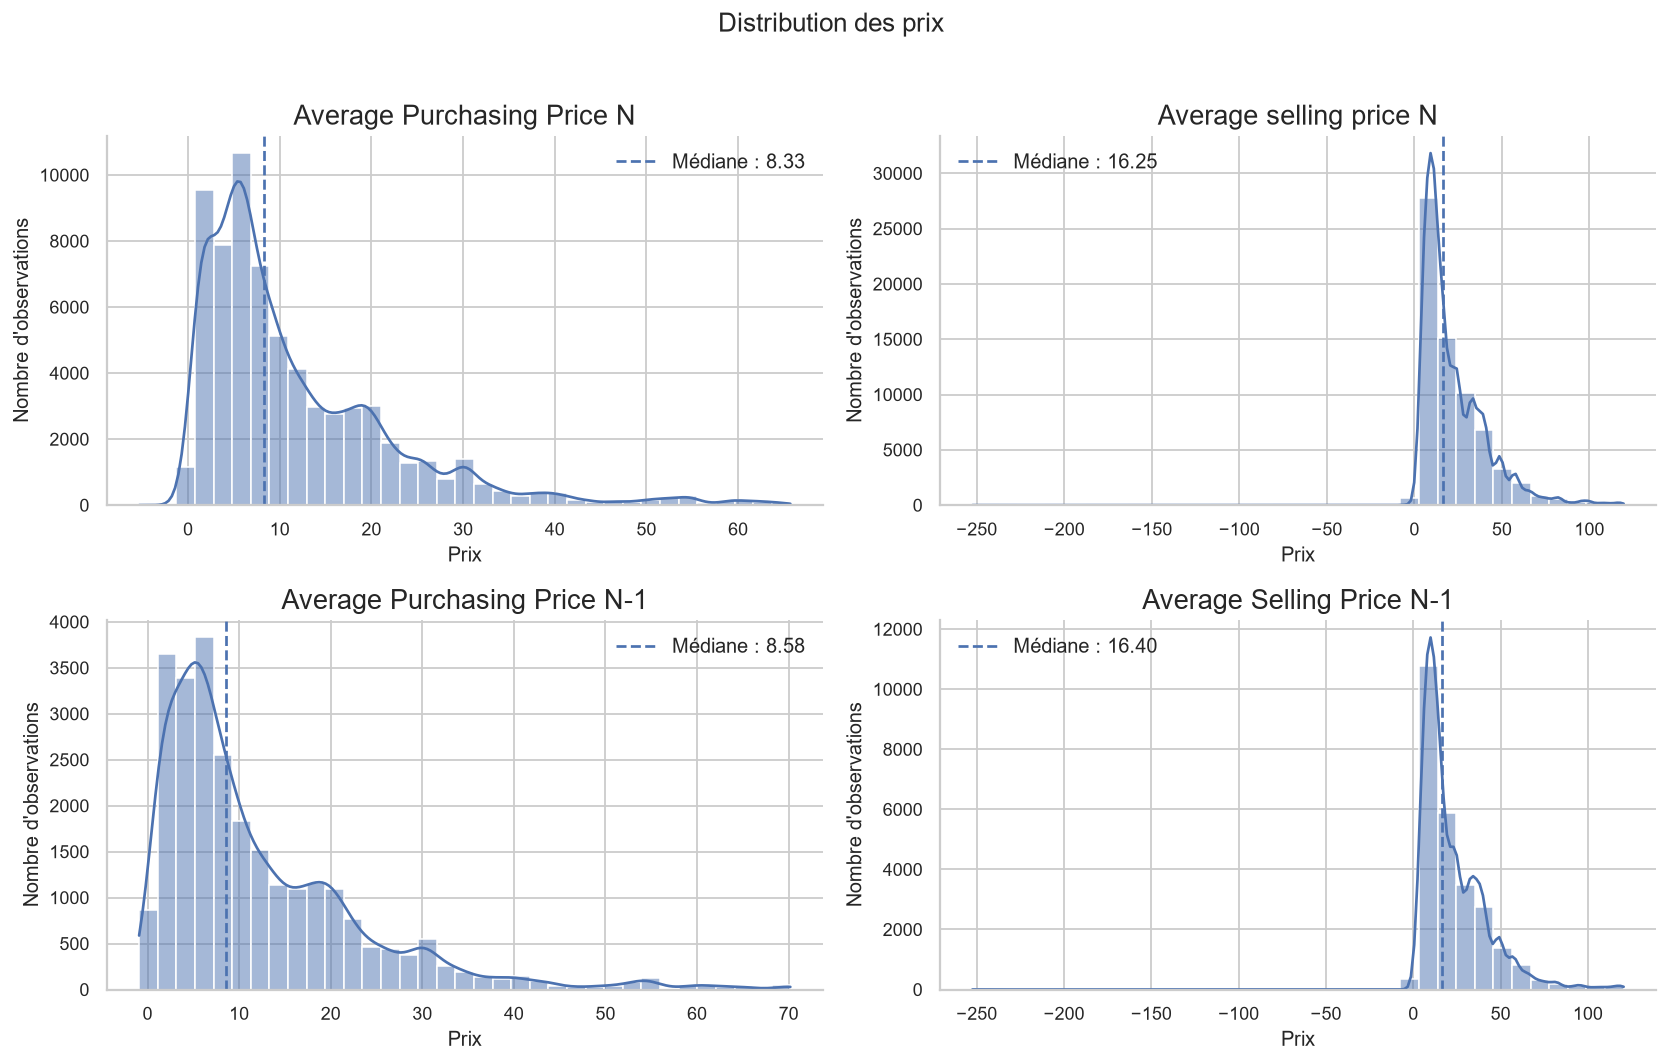

In [25]:
# Visualisation — distributions des prix

fig, axes = plt.subplots(
    2, 2,
    figsize=(13, 8)
)

for ax, column in zip(axes.flat, price_columns):
    values = df[column].dropna()

    if values.empty:
        ax.set_visible(False)
        continue

    upper = values.quantile(0.99)
    plot_values = values[values <= upper]

    sns.histplot(
        plot_values,
        bins=35,
        kde=True,
        ax=ax
    )

    ax.set_title(column)
    ax.set_xlabel("Prix")
    ax.set_ylabel("Nombre d'observations")
    ax.axvline(
        values.median(),
        linestyle="--",
        linewidth=1.5,
        label=f"Médiane : {values.median():.2f}"
    )
    ax.legend()

fig.suptitle(
    "Distribution des prix ",
    y=1.02
)

sns.despine()
plt.tight_layout()
plt.show()

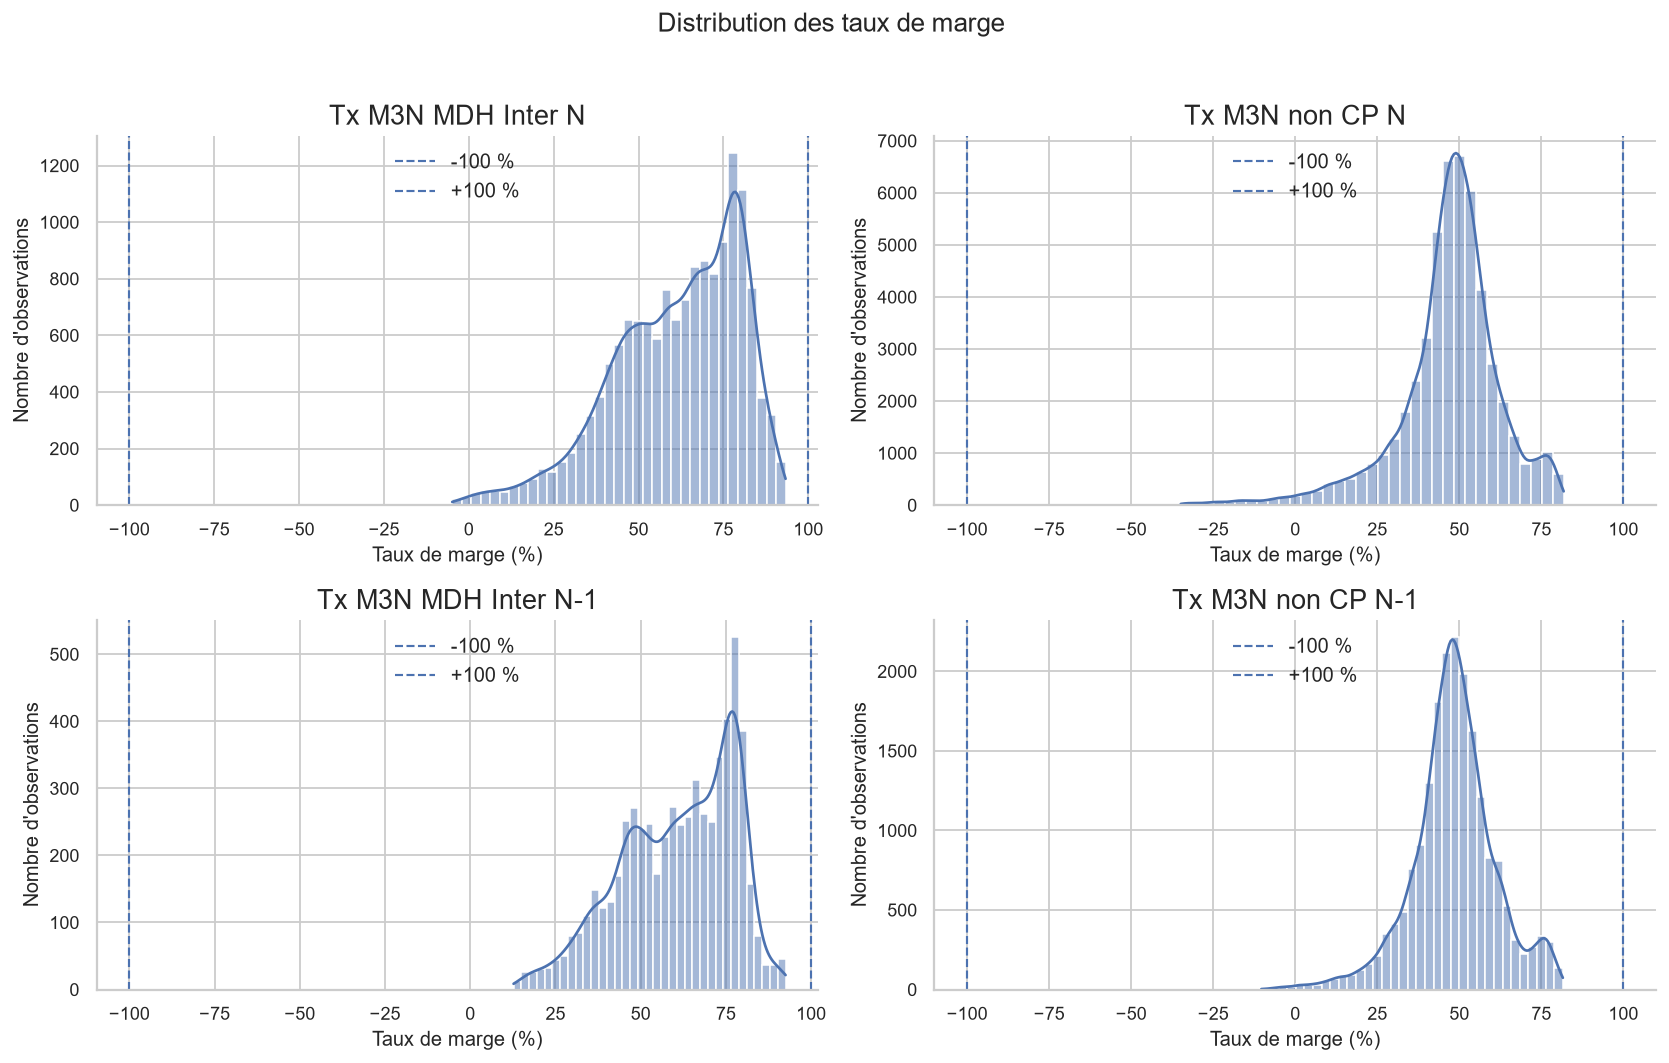

In [24]:
# Visualisation — distributions des taux de marge

fig, axes = plt.subplots(
    2, 2,
    figsize=(13, 8)
)

for ax, column in zip(axes.flat, margin_columns):
    values = df[column].dropna()

    if values.empty:
        ax.set_visible(False)
        continue

    lower = values.quantile(0.01)
    upper = values.quantile(0.99)

    plot_values = values[
        values.between(lower, upper)
    ]

    sns.histplot(
        plot_values,
        bins=35,
        kde=True,
        ax=ax
    )

    ax.axvline(
        -100,
        linestyle="--",
        linewidth=1.2,
        label="-100 %"
    )

    ax.axvline(
        100,
        linestyle="--",
        linewidth=1.2,
        label="+100 %"
    )

    ax.set_title(column)
    ax.set_xlabel("Taux de marge (%)")
    ax.set_ylabel("Nombre d'observations")
    ax.legend()

fig.suptitle(
    "Distribution des taux de marge ",
    y=1.02
)

sns.despine()
plt.tight_layout()
plt.show()

In [26]:
# Synthèse des contrôles numériques

numeric_checks = pd.DataFrame({
    "Contrôle": [
        "Variables de prix",
        "Variables de marge",
        "Prix négatifs",
        "Prix nuls",
        "Marges > 100 %",
        "Marges < -100 %",
        "Années non attendues"
    ],
    "Résultat": [
        len(price_columns),
        len(margin_columns),
        int(negative_prices["Prix_négatifs"].sum()),
        int(zero_prices["Prix_nuls"].sum()),
        int(high_margin["Valeurs_supérieures_100"].sum()),
        int(low_margin["Valeurs_inférieures_-100"].sum()),
        len(invalid_years)
    ]
})

display(numeric_checks)

,Contrôle,Résultat
0,Variables de prix,4
1,Variables de marge,4
2,Prix négatifs,86
3,Prix nuls,20
4,Marges > 100 %,111
5,Marges < -100 %,246
6,Années non attendues,0


# Partie 6 — Contrôles de cohérence métier et temporelle

Cette étape vérifie les dimensions utilisées pour les comparaisons temporelles et hiérarchiques :

- modalités temporelles ;
- couverture historique des EAN ;
- continuité des périodes ;
- cohérence de la hiérarchie produit ;
- modalités catégorielles principales.

In [29]:
# Contrôle des variables catégorielles principales

categorical_columns = [
    "MonthLib",
    "International Department",
    "International Sub Department",
    "International Family",
    "Offer_Type"
]

categorical_columns = [
    column
    for column in categorical_columns
    if column in df.columns
]

categorical_summary = pd.DataFrame({
    "Variable": categorical_columns,
    "Modalites_uniques": [
        df[column].nunique(dropna=True)
        for column in categorical_columns
    ],
    "Valeurs_manquantes": [
        int(df[column].isna().sum())
        for column in categorical_columns
    ]
})

display(categorical_summary)

,Variable,Modalites_uniques,Valeurs_manquantes
0,MonthLib,12,0
1,International Department,3,0
2,International Sub Department,3,0
3,International Family,19,0


In [30]:
# Contrôle des mois disponibles

expected_months = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

unexpected_months = (
    df.loc[
        df["MonthLib"].notna()
        & ~df["MonthLib"].isin(expected_months),
        ["MonthLib"]
    ]
    .drop_duplicates()
    .sort_values("MonthLib")
)

print(f"Mois non conformes : {len(unexpected_months)}")

if len(unexpected_months) > 0:
    display(unexpected_months)

Mois non conformes : 0


In [31]:
# Couverture temporelle des EAN

ean_history = (
    df[df["EAN"].notna()]
    .groupby("EAN")
    .agg(
        Nb_Mois_Observes=("MonthLib", "nunique"),
        Premiere_Annee=("Year", "min"),
        Derniere_Annee=("Year", "max")
    )
    .reset_index()
)

history_summary = (
    ean_history["Nb_Mois_Observes"]
    .describe()
    .round(2)
)

print(f"EAN analysés : {len(ean_history):,}")
display(history_summary)

EAN analysés : 5,860


count    5860.00
mean        9.21
std         3.50
min         1.00
25%         7.00
50%        11.00
75%        12.00
max        12.00
Name: Nb_Mois_Observes, dtype: float64

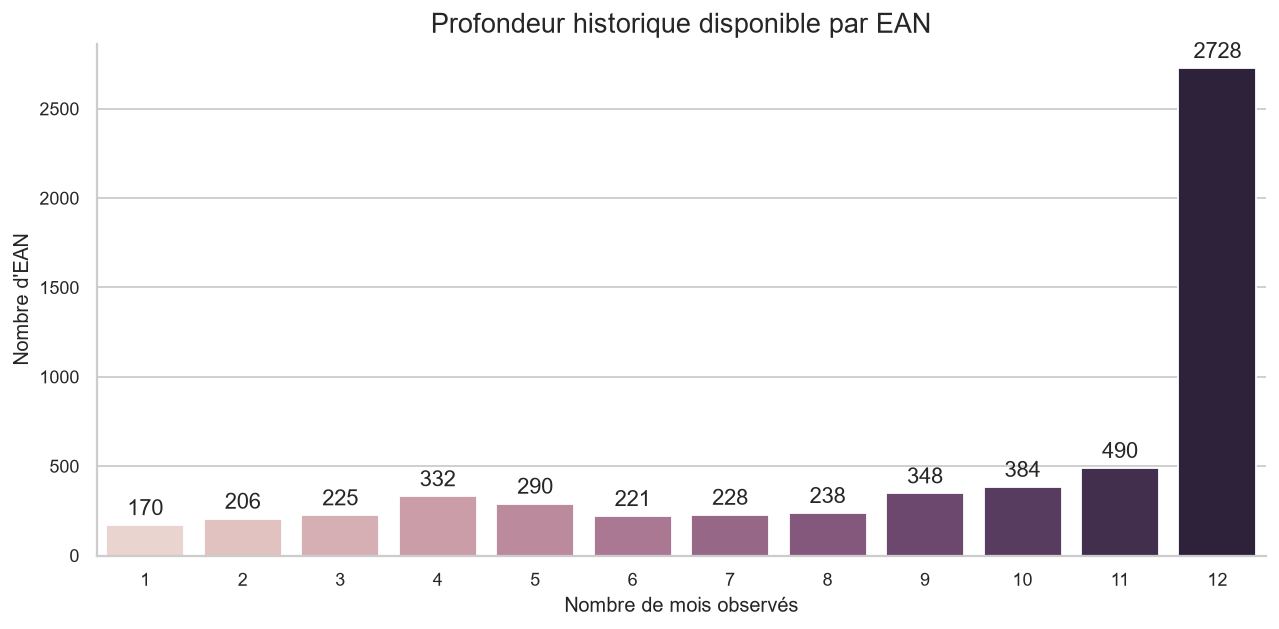

In [32]:
# Visualisation — profondeur historique par EAN

history_distribution = (
    ean_history["Nb_Mois_Observes"]
    .value_counts()
    .sort_index()
    .rename_axis("Nombre de mois observés")
    .reset_index(name="Nombre d'EAN")
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=history_distribution,
    x="Nombre de mois observés",
    y="Nombre d'EAN",
    hue="Nombre de mois observés",
    legend=False,
    ax=ax
)

ax.set_title("Profondeur historique disponible par EAN")
ax.set_xlabel("Nombre de mois observés")
ax.set_ylabel("Nombre d'EAN")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

sns.despine()
plt.tight_layout()
plt.show()

In [33]:
# Contrôle de continuité temporelle

month_mapping = {
    "January": 1,
    "February": 2,
    "March": 3,
    "April": 4,
    "May": 5,
    "June": 6,
    "July": 7,
    "August": 8,
    "September": 9,
    "October": 10,
    "November": 11,
    "December": 12
}

df_time_check = (
    df[
        df["EAN"].notna()
        & df["Year"].notna()
        & df["MonthLib"].notna()
    ][["EAN", "Year", "MonthLib"]]
    .drop_duplicates()
    .copy()
)

df_time_check["Month_Number"] = (
    df_time_check["MonthLib"]
    .astype(str)
    .str.strip()
    .map(month_mapping)
)

invalid_month_labels = df_time_check["Month_Number"].isna()

if invalid_month_labels.any():
    display(
        df_time_check.loc[
            invalid_month_labels,
            ["Year", "MonthLib"]
        ].drop_duplicates()
    )
    raise ValueError(
        "Certains MonthLib ne correspondent pas aux 12 mois attendus."
    )

df_time_check["Period_Index"] = (
    df_time_check["Year"].astype(int) * 12
    + df_time_check["Month_Number"].astype(int)
)

temporal_continuity = (
    df_time_check
    .sort_values(["EAN", "Period_Index"])
    .groupby("EAN")
    .agg(
        Premiere_Periode=("Period_Index", "min"),
        Derniere_Periode=("Period_Index", "max"),
        Nb_Mois=("Period_Index", "nunique")
    )
    .reset_index()
)

temporal_continuity["Duree_Calendaire_Mois"] = (
    temporal_continuity["Derniere_Periode"]
    - temporal_continuity["Premiere_Periode"]
    + 1
)

temporal_continuity["Nb_Mois_Absents"] = (
    temporal_continuity["Duree_Calendaire_Mois"]
    - temporal_continuity["Nb_Mois"]
)

incomplete_history = temporal_continuity[
    temporal_continuity["Nb_Mois_Absents"] > 0
]

print(f"EAN analysés : {len(temporal_continuity):,}")
print(
    "EAN avec au moins un mois absent dans leur période d'observation : "
    f"{len(incomplete_history):,}"
)

if not incomplete_history.empty:
    display(
        incomplete_history
        .sort_values("Nb_Mois_Absents", ascending=False)
        .head(20)
    )

EAN analysés : 5,860
EAN avec au moins un mois absent dans leur période d'observation : 1,907


,EAN,Premiere_Periode,Derniere_Periode,Nb_Mois,Duree_Calendaire_Mois,Nb_Mois_Absents
431,3.083293e+12,24301,24318,5,18,13
4974,3.700412e+12,24301,24317,4,17,13
4645,3.700301e+12,24303,24318,4,16,12
287,3.083293e+12,24301,24317,5,17,12
3187,3.663406e+12,24302,24317,4,16,12
519,3.083293e+12,24301,24317,5,17,12
4556,3.700301e+12,24302,24318,5,17,12
3399,3.663655e+12,24301,24317,5,17,12
457,3.083293e+12,24302,24317,4,16,12
3274,3.663406e+12,24304,24316,2,13,11


In [34]:
# Cohérence de la hiérarchie produit

family_mapping = (
    df[
        [
            "International Family",
            "International Sub Department",
            "International Department"
        ]
    ]
    .dropna(subset=["International Family"])
    .groupby("International Family")
    .agg(
        Nb_Sous_Departements=(
            "International Sub Department",
            "nunique"
        ),
        Nb_Departements=(
            "International Department",
            "nunique"
        )
    )
    .reset_index()
)

hierarchy_inconsistencies = family_mapping[
    (family_mapping["Nb_Sous_Departements"] > 1)
    | (family_mapping["Nb_Departements"] > 1)
].copy()

print(f"Familles contrôlées : {len(family_mapping):,}")
print(
    "Familles présentant une incohérence : "
    f"{len(hierarchy_inconsistencies):,}"
)

if not hierarchy_inconsistencies.empty:
    display(hierarchy_inconsistencies)

Familles contrôlées : 19
Familles présentant une incohérence : 0


# Partie 7 — Synthèse de l'audit

Cette synthèse rassemble les principaux contrôles nécessaires avant le prétraitement.


In [35]:
# Synthèse globale de l'audit

audit_summary = pd.DataFrame({
    "Contrôle": [
        "Nombre de lignes",
        "Nombre de colonnes",
        "Valeurs manquantes",
        "Taux global de valeurs manquantes (%)",
        "EAN manquants",
        "Doublons exacts",
        "Doublons métier",
        "Années non attendues",
        "Mois non conformes",
        "Prix négatifs",
        "Prix nuls",
        "Marges > 100 %",
        "Marges < -100 %",
        "Valeurs manquantes dans la hiérarchie",
        "EAN avec >= 12 mois d'historique",
        "EAN avec historique incomplet",
        "Familles avec incohérence hiérarchique"
    ],
    "Résultat": [
        len(df),
        df.shape[1],
        total_missing,
        round(global_missing_rate, 2),
        missing_ean,
        len(exact_duplicates),
        len(business_duplicates),
        len(invalid_years),
        len(unexpected_months),
        int(negative_prices["Prix_négatifs"].sum()),
        int(zero_prices["Prix_nuls"].sum()),
        int(high_margin["Valeurs_supérieures_100"].sum()),
        int(low_margin["Valeurs_inférieures_-100"].sum()),
        int(categorical_summary["Valeurs_manquantes"].sum()),
        int((ean_history["Nb_Mois_Observes"] >= 12).sum()),
        int((temporal_continuity["Nb_Mois_Absents"] > 0).sum()),
        len(hierarchy_inconsistencies)
    ]
})

display(audit_summary)

# Seule sortie persistante du notebook
audit_summary.to_csv(
    QUALITY_DIR / "audit_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print(f"Synthèse enregistrée : {QUALITY_DIR / 'audit_summary.csv'}")

,Contrôle,Résultat
0,Nombre de lignes,74888.00
1,Nombre de colonnes,15.00
2,Valeurs manquantes,314174.00
3,Taux global de valeurs manquantes (%),27.97
4,EAN manquants,164.00
5,Doublons exacts,0.00
6,Doublons métier,0.00
7,Années non attendues,0.00
8,Mois non conformes,0.00
9,Prix négatifs,86.00


Synthèse enregistrée : C:\Users\20017459\Documents\Algo_3NM\data\results\data_quality\audit_summary.csv


# Conclusion

L'audit confirme la structure du dataset intégré et met en évidence les principales situations à prendre en compte avant le prétraitement :

- valeurs manquantes, notamment sur les indicateurs historiques ;
- quelques incohérences numériques sur les prix et les taux de marge ;
- absence de doublons exacts et de doublons métier ;
- cohérence des périodes et de la hiérarchie produit ;
- disponibilité historique variable selon les EAN.

Les observations identifiées sont conservées dans le dataset. Leur traitement et leur interprétation sont réalisés dans les notebooks suivants, en fonction de leur nature et de leur rôle dans la détection des comportements atypiques.